In [22]:
# from pyvbmc import VBMC, VariationalPosterior
# vp = VariationalPosterior()
import pickle
model_name = 'sample_select'
with open(f'/home/andrew/abm_violence/data/warm_start_{model_name}.pkl', 'rb') as f:
    data = pickle.load(f)
sample_eval = data['sample_eval']
samples = data['samples'][:len(sample_eval), :]  # Align samples with evaluations

In [23]:
import numpy as np
sample_eval = np.array(sample_eval)
sample_eval.min(), sample_eval.max()
# import matplotlib.pyplot as plt
# plt.hist(sample_eval, bins=np.linspace(-2000, -800, 100))
# plt.show()

(np.float64(-266014.3660944113), np.float64(-816.4919847811326))

In [24]:
from gvabm.param_distr import ParamDistr, param_config
param_distr = ParamDistr(param_config)
filter_mask = sample_eval > -1500
fsamples = samples[filter_mask]
fsample_eval = (np.array(sample_eval)[filter_mask] - sample_eval.max())
fsample_likelihood = np.exp(fsample_eval - fsample_eval.max())
fsamples.shape, fsample_likelihood.shape

((2437, 5), (2437,))

In [25]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, WhiteKernel, ConstantKernel as C
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

train_mask = np.random.rand(len(fsample_eval)) < 0.8
train_samples = fsamples[train_mask]
train_evals = fsample_eval[train_mask]
test_samples = fsamples[~train_mask]
test_evals = fsample_eval[~train_mask]
# Prepare data for GP fitting
X_gp = train_samples  # Shape: (N, 5)
y_gp = train_evals  # Shape: (N,)

print(f"GP training data shape: X={X_gp.shape}, y={y_gp.shape}")
print(f"y range: [{y_gp.min():.3f}, {y_gp.max():.3f}]")

# Standardize the input features for better GP performance
scaler_X = StandardScaler()
X_gp_scaled = scaler_X.fit_transform(X_gp)
test_scaled = scaler_X.transform(test_samples)

# Define kernel - using RBF + White noise for robustness
kernel = C(1.0, (1e-3, 1e5)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) + WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-10, 2e+1))

print("Fitting Gaussian Process...")
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, random_state=42)
gp.fit(X_gp_scaled, y_gp)

print(f"Fitted GP kernel: {gp.kernel_}")
print(f"Log marginal likelihood: {gp.log_marginal_likelihood():.3f}")

# Make predictions on training data to check fit quality
y_pred, y_std = gp.predict(test_scaled, return_std=True)
mse = np.mean((test_evals - y_pred)**2)
r2 = 1 - mse / np.var(y_gp)

print(f"GP fit quality:")
print(f"  MSE: {mse:.6f}")
print(f"  R²: {r2:.4f}")
print(f"  Mean prediction std: {np.mean(y_std):.4f}")

GP training data shape: X=(1953, 5), y=(1953,)
y range: [-683.189, 0.000]
Fitting Gaussian Process...
Fitted GP kernel: 316**2 * RBF(length_scale=0.865) + WhiteKernel(noise_level=20)
Log marginal likelihood: -11173.953
GP fit quality:
  MSE: 2286.329960
  R²: 0.9312
  Mean prediction std: 34.8311


/home/andrew/anaconda3/envs/gvabm/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/andrew/anaconda3/envs/gvabm/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 20.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


In [19]:
def plot_gp_heatmap(gp, scaler_X, X_original, y_original, i, j, ax, param_names=None, n_points=50):
    slice_center = np.mean(X_original, axis=0)
    # slice_center = X_original[np.argmax(y_original)]
    # Create parameter ranges
    param_i_range = np.linspace(X_original[:, i].min(), X_original[:, i].max(), n_points)
    param_j_range = np.linspace(X_original[:, j].min(), X_original[:, j].max(), n_points)
    param_i_mesh, param_j_mesh = np.meshgrid(param_i_range, param_j_range)
    
    # Create grid points (other parameters at mean)
    grid_points = np.tile(slice_center, (n_points * n_points, 1))
    grid_points[:, i] = param_i_mesh.flatten()
    grid_points[:, j] = param_j_mesh.flatten()
    
    # Scale grid points using the same scaler
    grid_points_scaled = scaler_X.transform(grid_points)
    
    # GP predictions
    grid_pred_mean, grid_pred_std = gp.predict(grid_points_scaled, return_std=True)
    grid_pred_mean = grid_pred_mean.reshape(n_points, n_points)
    grid_pred_std = grid_pred_std.reshape(n_points, n_points)

    im = ax.contourf(param_i_mesh, param_j_mesh, grid_pred_mean, levels=20, cmap='viridis', alpha=0.8)

In [ ]:
from gvabm.param_distr import ParamDistr, mixed_choice_param_config
param_distr = ParamDistr(mixed_choice_param_config)
gp_param_names = param_distr.param_names
# fig, ax = plt.subplots(1, 1, figsize=(6, 5))
fig, ax = plt.subplots(6, 6, figsize=(10, 10))
for ind in range(6):
    ax[-1, ind].set_xlabel(gp_param_names[ind])
    ax[ind, 0].set_ylabel(gp_param_names[ind])

for j in range(6):
    for i in range(6):
        y_param = gp_param_names[i]
        x_param = gp_param_names[j]
        if i > j:
            plot_gp_heatmap(gp, scaler_X, fsamples, fsample_eval, j, i, ax[i, j], param_names=gp_param_names)
            #clear xticks and yticks for all ax
            if i < 4:
                ax[i, j].set_xticks([])
                ax[i, j].set_xticklabels([])
                ax[i, j].set_xlabel('')
            if j > 0:
                ax[i, j].set_yticks([])
                ax[i, j].set_yticklabels([])
                ax[i, j].set_ylabel('')

        else:
            ax[i, j].axis('off')

fig.colorbar(ax[-1, 0].collections[0], ax=ax, orientation='vertical', fraction=0.02, pad=0.04)

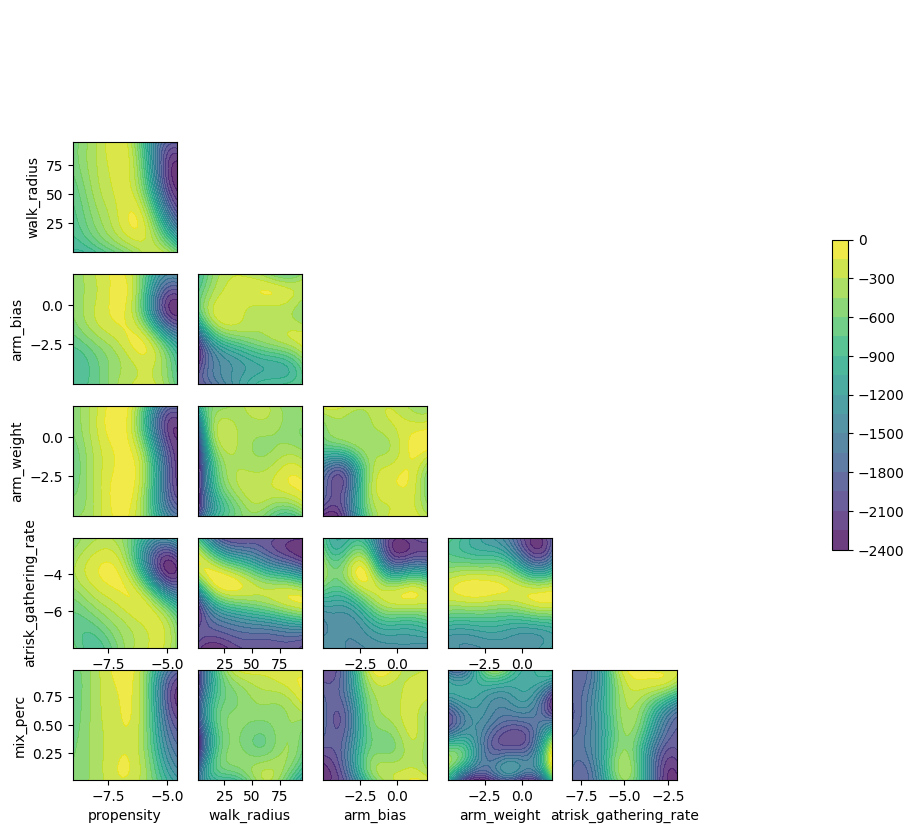

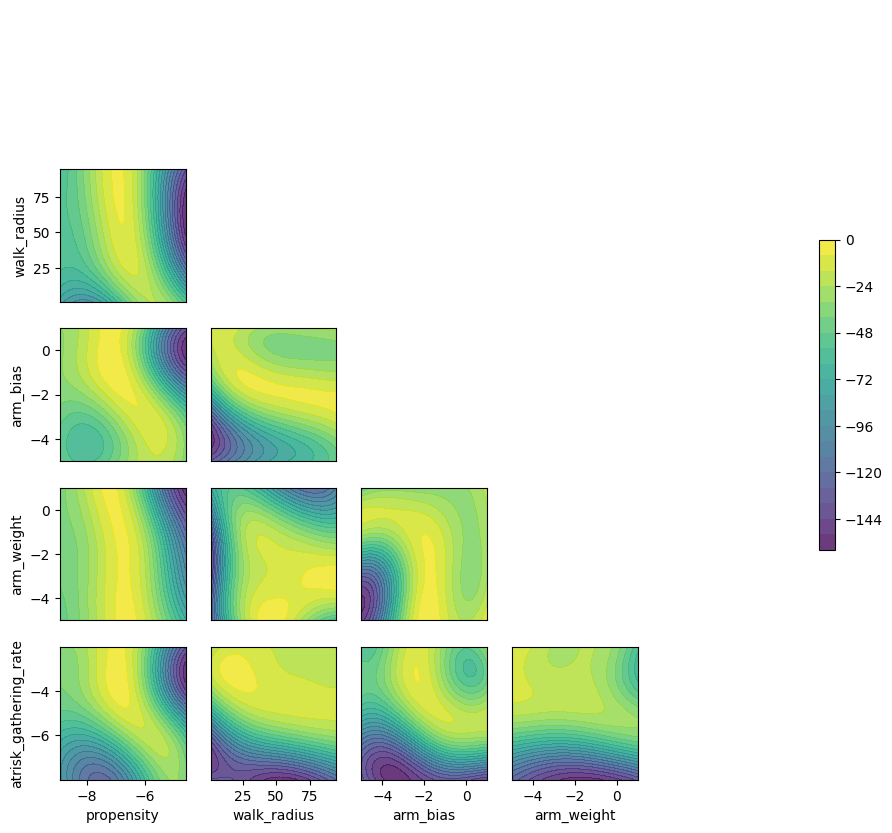

In [53]:
upper_bounds = param_distr.range_upper
lower_bounds = param_distr.range_lower
bound_widths = upper_bounds - lower_bounds
query_samples = np.random.uniform(low=lower_bounds, high=upper_bounds, size=(int(1e6), param_distr.param_count))
query_eval = gp.predict(scaler_X.transform(query_samples))

In [54]:
print(fsample_eval.min(), fsample_eval.max())

-38.337953161996495 0.0


In [59]:
print(f"Query eval range: [{query_eval.min():.3f}, {query_eval.max():.3f}]")
query_mask = query_eval > -30
q_samples = query_samples[query_mask]
q_eval = query_eval[query_mask]
print(f"Filtered query samples: {len(q_samples)} / {len(query_samples)}")

Query eval range: [-339.632, 11.095]
Filtered query samples: 273186 / 1000000


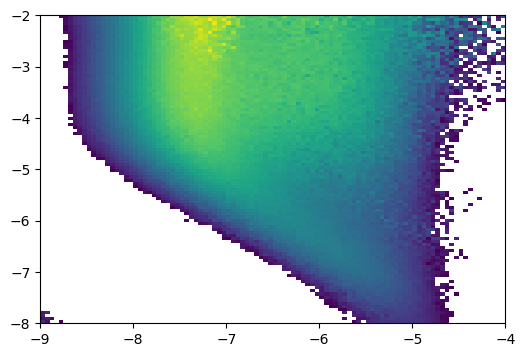

In [83]:
#plot 2D density of q_eval
plt.figure(figsize=(6, 4))
i, j = 0, 4
#use logscale cmap

plt.hist2d(q_samples[:, i], q_samples[:, j], bins=100, weights=np.exp((q_eval - q_eval.max())/1),
            range=[[lower_bounds[i], upper_bounds[i]], [lower_bounds[j], upper_bounds[j]]], cmap='viridis', norm=LogNorm())

plt.show()

In [ ]:
def plot_gp_uncertainty_analysis(gp, scaler_X, X_original, y_original, param_names=None):
    """
    Analyze GP uncertainty and compare predictions with actual data.
    """
    
    if param_names is None:
        param_names = [f'Param {i}' for i in range(X_original.shape[1])]
    
    # Get predictions for all training points
    X_scaled = scaler_X.transform(X_original)
    y_pred_mean, y_pred_std = gp.predict(X_scaled, return_std=True)
    
    # Create diagnostic plots
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Plot 1: Predicted vs Actual
    axes[0, 0].scatter(y_original, y_pred_mean, alpha=0.6, s=20)
    min_val, max_val = min(y_original.min(), y_pred_mean.min()), max(y_original.max(), y_pred_mean.max())
    axes[0, 0].plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect prediction')
    axes[0, 0].set_xlabel('Actual Values')
    axes[0, 0].set_ylabel('GP Predictions')
    axes[0, 0].set_title('GP Predictions vs Actual Values')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Plot 2: Residuals vs Predictions
    residuals = y_original - y_pred_mean
    axes[0, 1].scatter(y_pred_mean, residuals, alpha=0.6, s=20)
    axes[0, 1].axhline(y=0, color='r', linestyle='--')
    axes[0, 1].set_xlabel('GP Predictions')
    axes[0, 1].set_ylabel('Residuals')
    axes[0, 1].set_title('Residuals vs Predictions')
    axes[0, 1].grid(True, alpha=0.3)
    
    # Plot 3: Uncertainty (std) distribution
    axes[1, 0].hist(y_pred_std, bins=30, alpha=0.7, edgecolor='black')
    axes[1, 0].set_xlabel('Prediction Standard Deviation')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].set_title('Distribution of GP Uncertainty')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Plot 4: Uncertainty vs Residuals (should be correlated)
    abs_residuals = np.abs(residuals)
    axes[1, 1].scatter(y_pred_std, abs_residuals, alpha=0.6, s=20)
    axes[1, 1].set_xlabel('Prediction Standard Deviation')
    axes[1, 1].set_ylabel('Absolute Residuals')
    axes[1, 1].set_title('Uncertainty vs Absolute Residuals')
    axes[1, 1].grid(True, alpha=0.3)
    
    # Add correlation coefficient
    corr_coef = np.corrcoef(y_pred_std, abs_residuals)[0, 1]
    axes[1, 1].text(0.05, 0.95, f'Correlation: {corr_coef:.3f}', 
                    transform=axes[1, 1].transAxes, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print("GP Performance Summary:")
    print(f"  Mean Absolute Error: {np.mean(np.abs(residuals)):.6f}")
    print(f"  Root Mean Square Error: {np.sqrt(np.mean(residuals**2)):.6f}")
    print(f"  R² Score: {1 - np.var(residuals) / np.var(y_original):.4f}")
    print(f"  Mean Prediction Uncertainty: {np.mean(y_pred_std):.6f}")
    print(f"  Uncertainty-Residual Correlation: {corr_coef:.4f}")
    
    return y_pred_mean, y_pred_std, residuals

# Run uncertainty analysis
y_pred_mean, y_pred_std, residuals = plot_gp_uncertainty_analysis(gp, scaler_X, fsamples, fsample_eval, gp_param_names)

In [26]:
from gvabm.param_distr import ParamDistr, param_config
param_distr = ParamDistr(param_config)
filter_mask = sample_eval > -900
fsamples = samples[filter_mask]
fsample_eval = (np.array(sample_eval)[filter_mask] - sample_eval.max())
fsample_likelihood = np.exp((fsample_eval - fsample_eval.max()) / 10)
fsamples.shape, fsample_likelihood.shape

((259, 5), (259,))

In [ ]:
fsample_eval_normed = fsample_eval + 800

In [ ]:
from pyvbmc import VBMC
D = param_distr.param_count
LB = np.full((1, D), -np.inf); UB = np.full((1, D), np.inf)
PLB = param_distr.range_lower.reshape((1, -1)); PUB = param_distr.range_upper.reshape((1, -1))
from gvabm.abm_vbmc import get_param_density_func_noisy

options = {
    "max_fun_evals": 150 * (D + 2),
    "specify_target_noise": True, 
    "f_vals": fsample_eval_normed,
}
from gvabm.abm_vbmc import conditional_sample_noselection
sample_func = conditional_sample_noselection
density_func = get_param_density_func_noisy(sample_func, param_distr, jrand.PRNGKey(2), 
                                            num_samples=50000, cutoff_likelihood=-1050)
P = density_func

(259, 5)

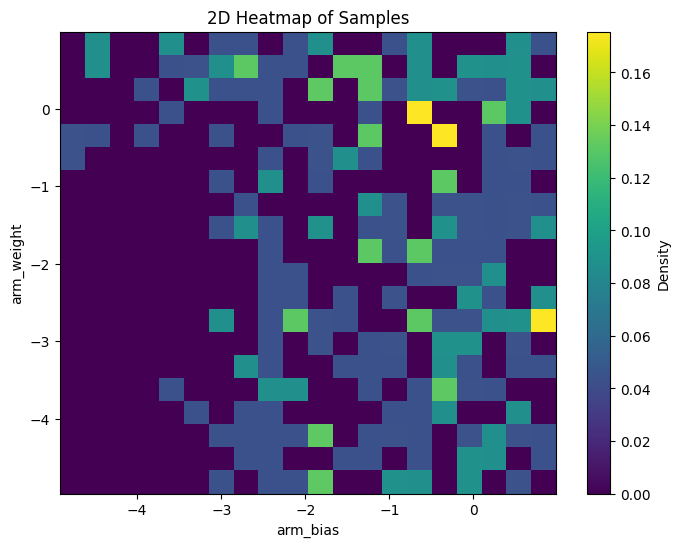

In [32]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
i, j = 2, 3
plt.figure(figsize=(8, 6))
plt.hist2d(fsamples[:, i], fsamples[:, j], bins=20, density=True, cmap='viridis') #, norm=LogNorm())
plt.colorbar(label='Density')
plt.xlabel(param_distr.param_names[i])
plt.ylabel(param_distr.param_names[j])
plt.title('2D Heatmap of Samples')
plt.show()

plotted


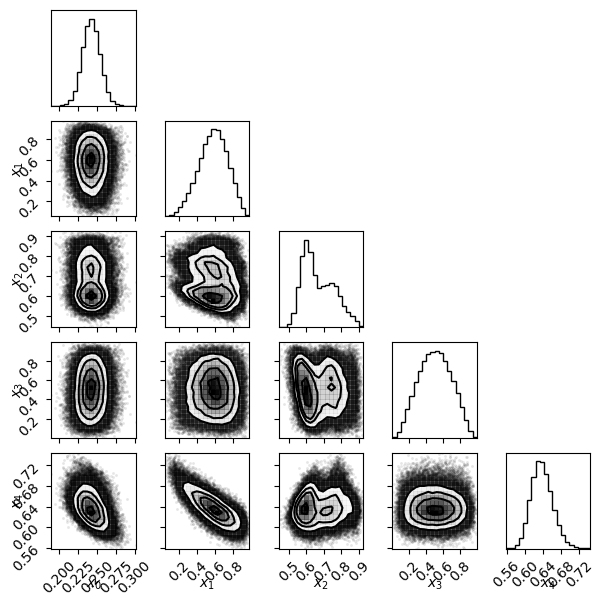

In [1]:
import dill
with open("/home/andrew/abm_violence/models/max_select-v15/vbmc.pkl", "rb") as f:
    vbmc_loaded = dill.load(f)
vp = vbmc_loaded.vp
vp.plot()
print("plotted")

plotted


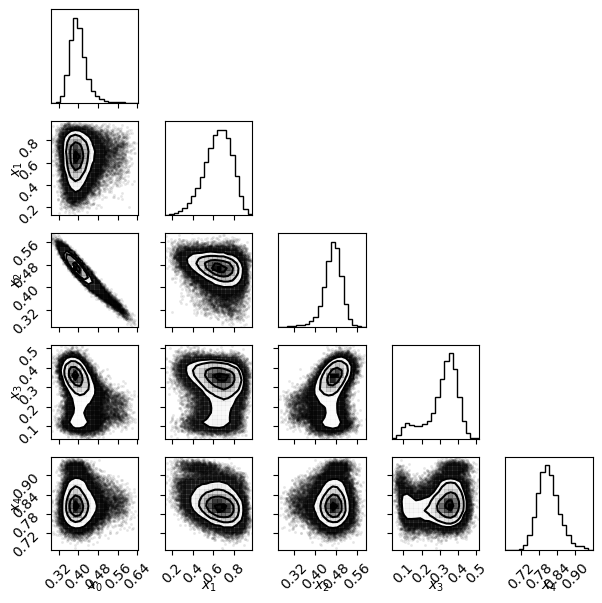

In [2]:
import dill
with open("/home/andrew/abm_violence/models/sample_select-v17/vbmc.pkl", "rb") as f:
    vbmc_loaded = dill.load(f)
vp = vbmc_loaded.vp
vp.plot()
print("plotted")

plotted


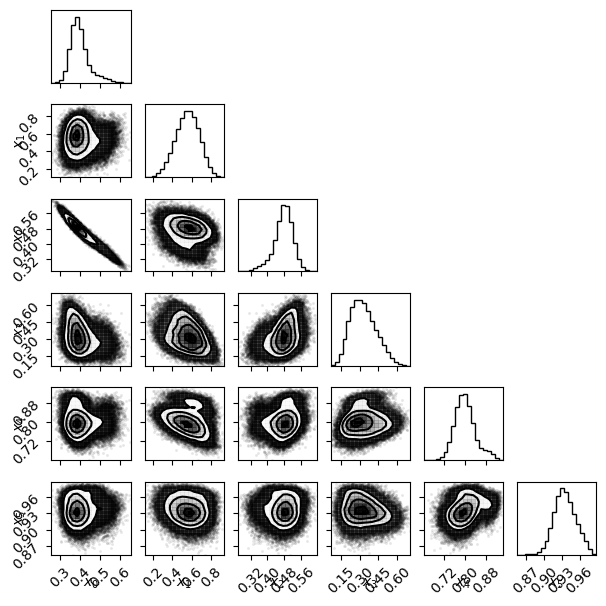

In [3]:
import dill
with open("/home/andrew/abm_violence/models/mixed_choice-v9/vbmc.pkl", "rb") as f:
    vbmc_loaded = dill.load(f)
vp = vbmc_loaded.vp
vp.plot()
print("plotted")

plotted


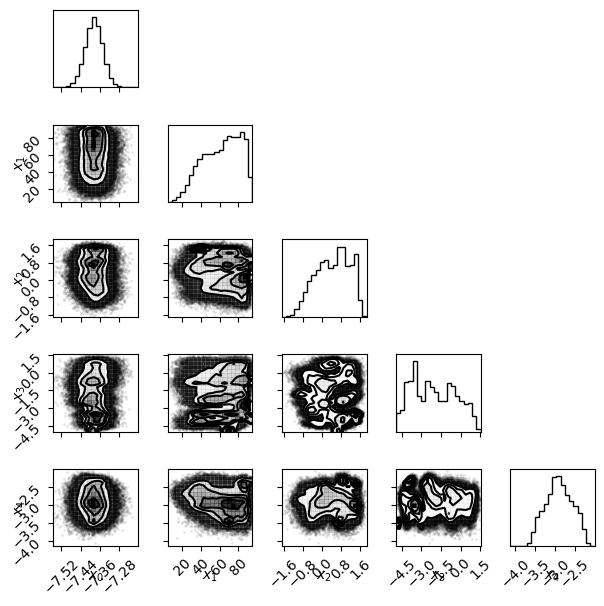

In [1]:
import dill
with open("/home/andrew/abm_violence/models/max_select-v10/vbmc.pkl", "rb") as f:
    vbmc_loaded = dill.load(f)
vp = vbmc_loaded.vp
vp.plot()
print("plotted")

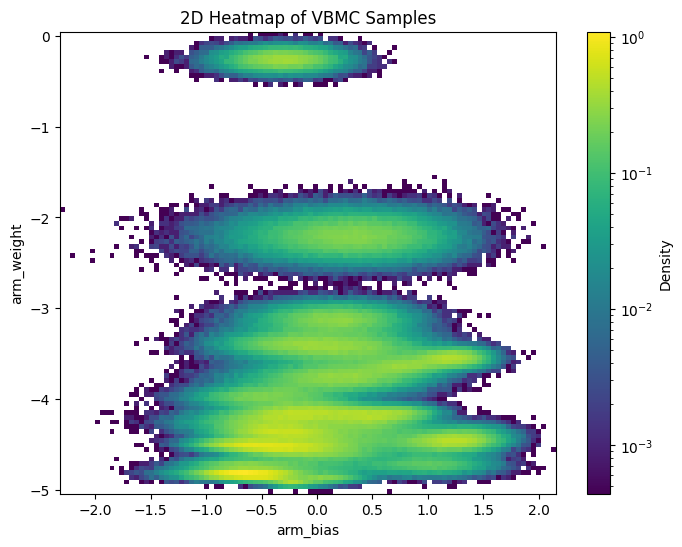

In [19]:
samples, _ = vp.sample(int(1e6))
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
i, j = 2, 3
plt.figure(figsize=(8, 6))
from gvabm.param_distr import ParamDistr, param_config
param_distr = ParamDistr(param_config)
plt.hist2d(samples[:, i], samples[:, j], bins=100, density=True,
            cmap='viridis', norm=LogNorm())
plt.colorbar(label='Density')
plt.xlabel(param_distr.param_names[i])
plt.ylabel(param_distr.param_names[j])
plt.title('2D Heatmap of VBMC Samples')
plt.show()

plotted


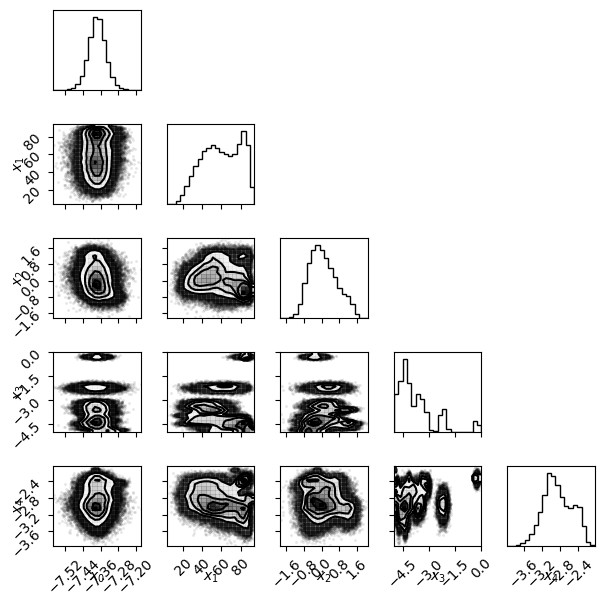

In [2]:
import dill
with open("/home/andrew/abm_violence/models/sample_select-v11/vbmc.pkl", "rb") as f:
    vbmc_loaded = dill.load(f)
vp = vbmc_loaded.vp
vp.plot()
print("plotted")

plotted


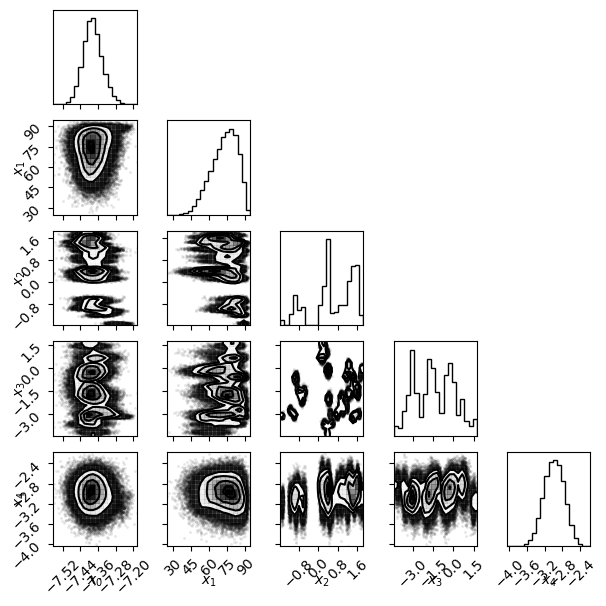

In [1]:
import dill
with open("/home/andrew/abm_violence/models/max_select-v9/vbmc.pkl", "rb") as f:
    vbmc_loaded = dill.load(f)
vp = vbmc_loaded.vp
vp.plot()
print("plotted")

In [ ]:

import dill
with open("/home/andrew/abm_violence/models/sample_select-v6/vbmc.pkl", "rb") as f:
    vbmc_loaded = dill.load(f)
vp = vbmc_loaded.vp
vp.plot()
print('plotted')

plotted


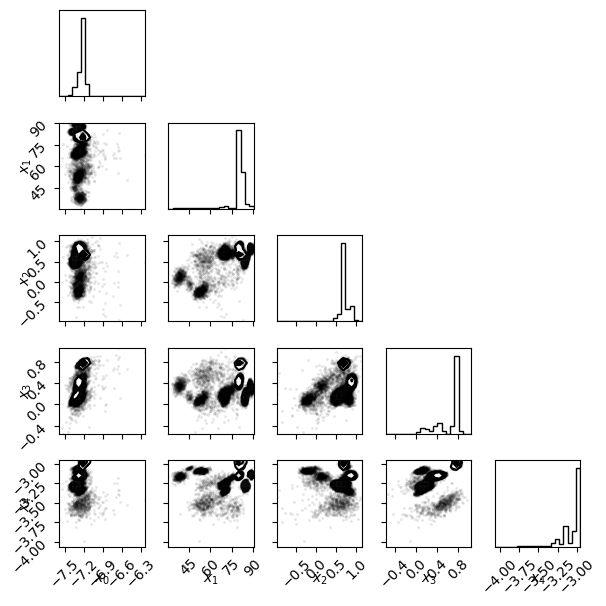

In [17]:
import argparse
import os


import logging
import pickle
import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
import jax.random as jrand

from gvabm.abm_event import conditional_sample, conditional_sample_noselection, conditional_sample_mixed
from gvabm.abm_ll import city_ll, eval_ds
from gvabm.stat_utils import logrange
from gvabm.param_distr import ParamDistr, param_config, mixed_choice_param_config, CityParams, EventOutcome, GeneralParams, MixedGeneralParams
from gvabm.abm_vbmc import get_param_density_func_noisy

model_name = 'sample_select'
sample_func = {'max_select': conditional_sample, 'sample_select': conditional_sample_noselection, 'mixed_choice': conditional_sample_mixed}[model_name]
param_config = {'max_select': param_config, 'sample_select': param_config, 'mixed_choice': mixed_choice_param_config}[model_name]
cutoff_likelihood = {'max_select': -920, 'sample_select': -920, 'mixed_choice': -920}[model_name]

param_distr = ParamDistr(param_config)
prior = param_distr.get_uniform_prior()

from pyvbmc import VBMC
D = param_distr.param_count
LB = np.full((1, D), -np.inf); UB = np.full((1, D), np.inf)
PLB = param_distr.range_lower.reshape((1, -1)); PUB = param_distr.range_upper.reshape((1, -1))
print('Parameter bounds:')
print('LB:', LB)
print('UB:', UB)
print('PLB:', PLB)
print('PUB:', PUB)

x0_options = {'max_select': np.array([-7.224117, 86.68149, -0.8460881, -0.28049266, -4.0412545]),
            'sample_select': np.array([-7.224117, 86.68149, -0.8460881, -0.28049266, -4.0412545]),
            'mixed_choice': np.array([-7.224117, 86.68149, -0.8460881, -0.28049266, -4.0412545, 0.96])}
x0 = x0_options[model_name]

x0 = np.array([[-7.224117, 86.68149, -0.8460881, -0.28049266, -4.0412545],
                [-7.0, 86.68149, -0.8460881, -0.28049266, -4.1412545],
                [-7.4, 86.68149, -0.8460881, -0.28049266, -3.9],
                [-7.5, 86.68149, -0.8460881, -0.28049266, -3.8],
                [-6.8, 86.68149, -0.8460881, -0.28049266, -4.3],
                ])

model_data = {'model_name': model_name, 'param_config': param_config, 'x0': x0}
#Add v-n to model_name if dir already exists

import os
options = {
    "max_fun_evals": 15,
    # "max_fun_evals": 5,
    "specify_target_noise": True, 
    "warmup_no_impro_threshold": 20 + 10 * D, 
}

model_dir = f'/home/andrew/abm_violence/models/{model_name}/'
if os.path.exists(model_dir):
    incr = 1
    while os.path.exists(f'/home/andrew/abm_violence/models/{model_name}-v{incr}/'):
        incr += 1
    model_dir = f'/home/andrew/abm_violence/models/{model_name}-v{incr}/'
os.makedirs(model_dir, exist_ok=True)

density_func = get_param_density_func_noisy(sample_func, param_distr, jrand.PRNGKey(1), 
                                            num_samples=6000, cutoff_likelihood=cutoff_likelihood, logdir=model_dir)
P = density_func

logfile = f"{model_dir}/vbmc.log"
logging.basicConfig(filename=logfile, level=logging.INFO)
with open(f"{model_dir}/model_data.pkl", "wb") as f:
    pickle.dump(model_data, f)

import json
with open(f"{model_dir}/model_desc.txt", "w") as f:
    json.dump({'model_name': model_name, 'x0': x0.tolist()}, f)

save_file = f"{model_dir}/model.pkl"
vbmc = VBMC(P, x0, LB, UB, PLB, PUB, options)
# vp, results = vbmc.optimize()
# vbmc.log_joint = None
# vbmc.function_logger = None

Parameter bounds:
LB: [[-inf -inf -inf -inf -inf]]
UB: [[inf inf inf inf inf]]
PLB: [[-9.   1.  -5.  -3.2 -8. ]]
PUB: [[-5 95  1  1 -4]]


In [18]:
vp, results = vbmc.optimize()

plotted


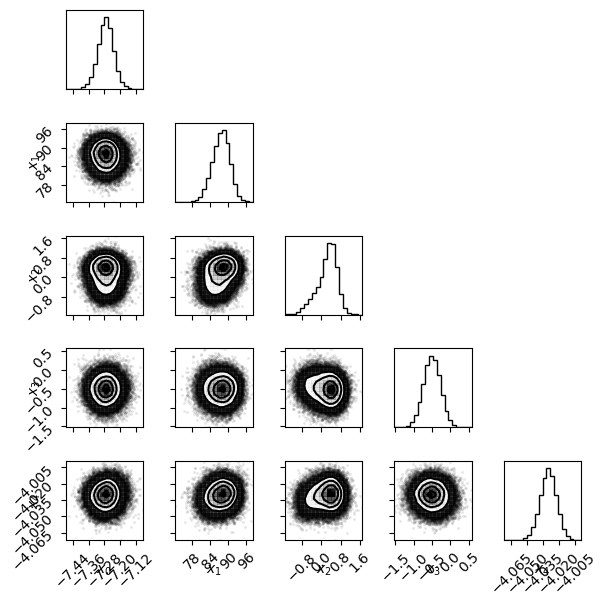

In [19]:
vp.plot()
print("plotted")

Text(0, 0.5, 'Convergence metric')

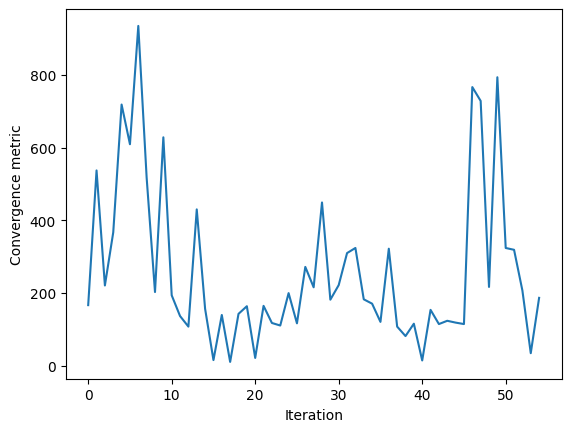

In [9]:
model_dir = f'/home/andrew/abm_violence/models/max_select-v7/'
with open(f"{model_dir}/density_eval.log", "r") as f:
    eval_log = f.readlines()
conv_l = []
for line in eval_log[100:]:
    if(line.startswith("INFO:VBMC:")):
        data = line.split()
        # print(data)
        try:
            convergence = int(data[-1])
        except ValueError:
            continue
        conv_l.append(convergence)
import matplotlib.pyplot as plt
plt.plot(conv_l)
plt.xlabel("Iteration")
plt.ylabel("Convergence metric")

In [ ]:

import pickle
import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
import jax.random as jrand

from gvabm.abm_event import sample_event, conditional_sample
from gvabm.abm_ll import city_ll, eval_ds
from gvabm.stat_utils import logrange
from gvabm.city_data import subsampled_city_data, subsample_weights
from gvabm.param_distr import ParamDistr, param_config, CityParams, EventOutcome, GeneralParams, MixedGeneralParams

In [37]:
model_dir = '/home/andrew/abm_violence/models/'
model_name = "sample_select"
model_path = f"{model_dir}/{model_name}/model.pkl"

In [40]:
from pyvbmc import VBMC

options = {
    "max_fun_evals": 50 * (5 + 2),
    "specify_target_noise": True
    
}
vbmc = VBMC.load(
        model_path,
        new_options=options,
        iteration=None,  # the default: start from the last stored iteration.
        set_random_state=False,  # the default: don't modify the random state
    )

EOFError: Ran out of input